# Mini Trabalho 3: Exploração dos Dados - Hábitos e Antecedentes de Risco

Esta seção explora os dados relacionados a hábitos e estilos de vida, além de antecedentes de risco à saúde de um indivíduo que podem influenciar no diagnóstico final.

### Bibliotecas Usadas e Configuração Inicial

Assim como nas seções anteriores, devemos importar as bibliotecas a seguir e salvar os dados em um dataset para preparar a ambiente de análise.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

def leitura_df():
    path_arquivo = 'data/alzheimers_disease_data.csv'
    if not os.path.exists(path_arquivo):
        path_arquivo = '../data/alzheimers_disease_data.csv'

    df_bruto = pd.read_csv(path_arquivo)

    df_bruto['Fumante_Label'] = df_bruto['Smoking'].map({0: 'Não', 1: 'Sim'})

    return df_bruto

df = leitura_df()

### Verificação de Integridade

Apesar de já ter sido feito anteriormente, é importante sempre realizar a verificação dos dados para garantir que não haja dados repetidos, nulos ou descartáveis antes de realizar qualquer tipo de exploração e análise.

In [39]:
def verificacao(dataframe):
    print(f"Total de registros na base: {len(dataframe)}")
    print(f"Registros duplicados (IDs): {dataframe['PatientID'].duplicated().sum()}")
    print(f"Valores nulos: {dataframe.isnull().sum().sum()}")
    print(f"Diversidade de Médicos: {dataframe['DoctorInCharge'].nunique()}") 

verificacao(df)

Total de registros na base: 2149
Registros duplicados (IDs): 0
Valores nulos: 0
Diversidade de Médicos: 1


### Consumo de Álcool e Cigarros

O consumo dessas substâncias em grande excesso impacta fortemente o desenvolvimento cerebral, alterando a funcionalidade e a estrutura do cérebro. Além disso, está ligado à deficiência de vitaminas para neurônios, a problemas vasculares e ao estresse. É importante analisar a influência desses hábitos no desenvolvimento de Alzheimer. Os valores dos gráficos abaixo indicam que, apesar de terem influência, o consumo desses produtos não é a principal causa da doença.

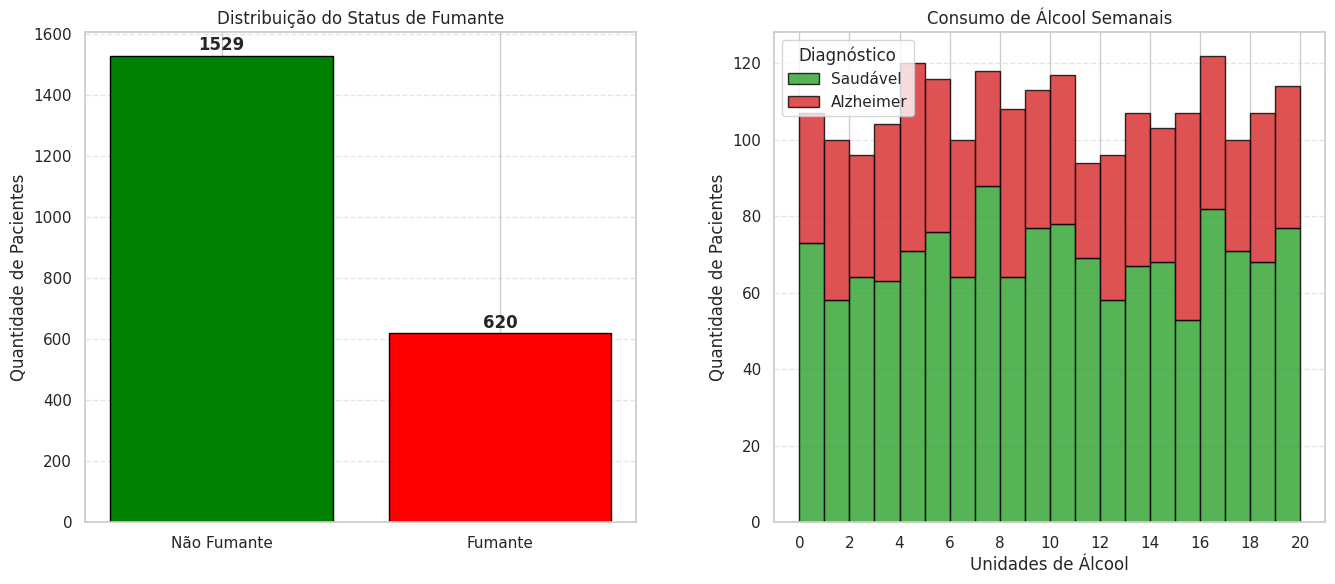

In [40]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

contagem_smoking = df['Smoking'].value_counts().sort_index()
barras_smoking = ax1.bar(['Não Fumante', 'Fumante'], contagem_smoking, color=['green', 'red'], edgecolor='black')
ax1.set_title('Distribuição do Status de Fumante')
ax1.set_ylabel('Quantidade de Pacientes')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in barras_smoking:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')

alc_saudavel = df[df['Diagnosis'] == 0]['AlcoholConsumption'].dropna()
alc_alzheimer = df[df['Diagnosis'] == 1]['AlcoholConsumption'].dropna()

ax2.hist([alc_saudavel, alc_alzheimer], bins=20, range=(0, 20), stacked=True, 
         color=['#2ca02c', '#d62728'], label=['Saudável', 'Alzheimer'], edgecolor='black', alpha=0.8)

ax2.set_title('Consumo de Álcool Semanais')
ax2.set_xlabel('Unidades de Álcool')
ax2.set_ylabel('Quantidade de Pacientes')
ax2.set_xticks(range(0, 21, 2))
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend(title="Diagnóstico")

plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)
plt.show()

### Qualidade do Sono e Atividade Física

Um bom sono e atividade física são os momentos ideais para o 'relaxamento' do seu cérebro. O número de pessoas com Alzheimer demonstra uma diminuição em relação ao número de pessoas saudáveis em casos de alta qualidade de sono.

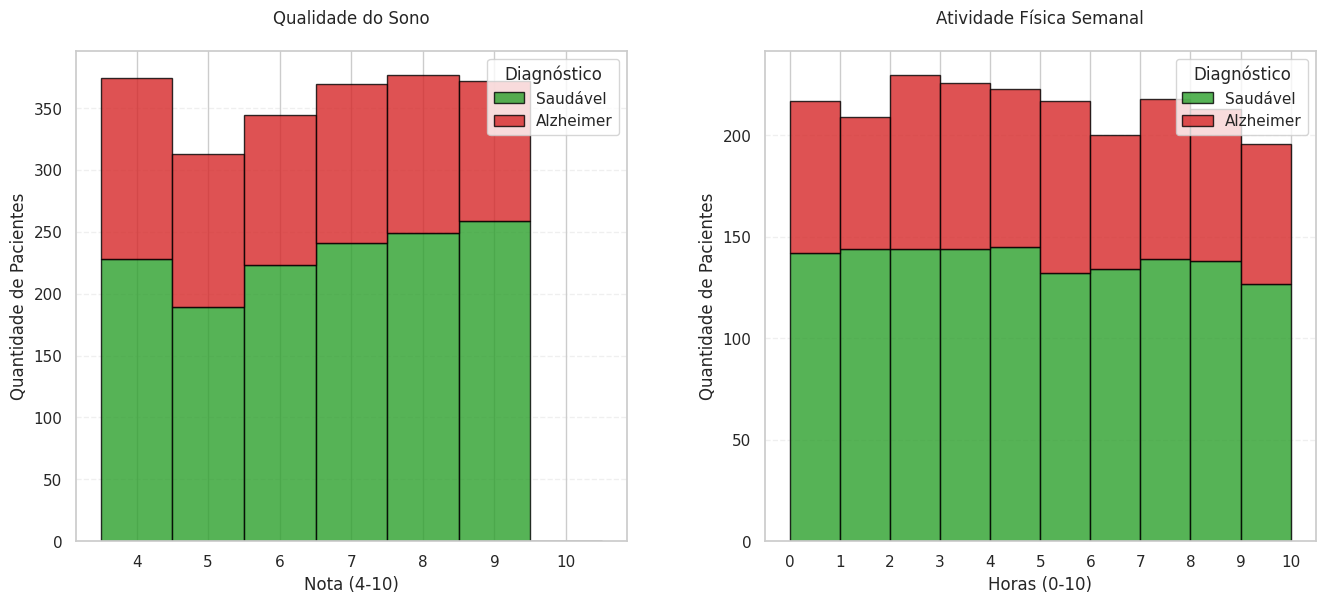

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sleep_saudavel = df[df['Diagnosis'] == 0]['SleepQuality'].dropna()
sleep_alzheimer = df[df['Diagnosis'] == 1]['SleepQuality'].dropna()

ax1.hist([sleep_saudavel, sleep_alzheimer], bins=7, range=(4, 11), stacked=True, 
         color=['#2ca02c', '#d62728'], label=['Saudável', 'Alzheimer'], edgecolor='black', alpha=0.8, align='left')

ax1.set_title('Qualidade do Sono', pad=20)
ax1.set_xlabel('Nota (4-10)')
ax1.set_ylabel('Quantidade de Pacientes')
ax1.set_xticks(range(4, 11))
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(title="Diagnóstico")

phys_saudavel = df[df['Diagnosis'] == 0]['PhysicalActivity'].dropna()
phys_alzheimer = df[df['Diagnosis'] == 1]['PhysicalActivity'].dropna()

ax2.hist([phys_saudavel, phys_alzheimer], bins=10, range=(0, 10), stacked=True, 
         color=['#2ca02c', '#d62728'], label=['Saudável', 'Alzheimer'], edgecolor='black', alpha=0.8)

ax2.set_title('Atividade Física Semanal', pad=20)
ax2.set_xlabel('Horas (0-10)')
ax2.set_ylabel('Quantidade de Pacientes')
ax2.set_xticks(range(0, 11))
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(title="Diagnóstico")

plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.25)
plt.show()

### IMC e Qualidade da Dieta.

A obesidade pode ser um fator prejudicial à saúde; é importante seguir uma dieta balanceada e de qualidade para evitar problemas de inflamação de sistemas, que podem afetar o cérebro.

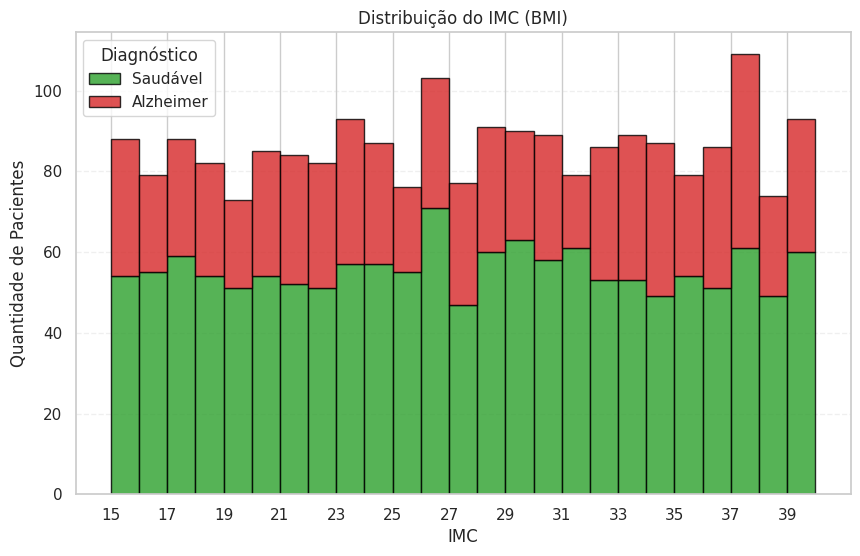

In [42]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

bmi_0 = df[df['Diagnosis'] == 0]['BMI'].dropna()
bmi_1 = df[df['Diagnosis'] == 1]['BMI'].dropna()

ax1.hist([bmi_0, bmi_1], bins=25, range=(15, 40), stacked=True, 
         color=['#2ca02c', '#d62728'], label=['Saudável', 'Alzheimer'], edgecolor='black', alpha=0.8)

ax1.set_title('Distribuição do IMC (BMI)')
ax1.set_xlabel('IMC')
ax1.set_ylabel('Quantidade de Pacientes')
ax1.set_xticks(range(15, 41, 2))
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(title="Diagnóstico")

plt.show()

### Gráfico de Correlação

Podemos fazer um gráfico de correlação para análisar melhor como esses dados se relacionam. Os resultados não demonstram alta correlação.

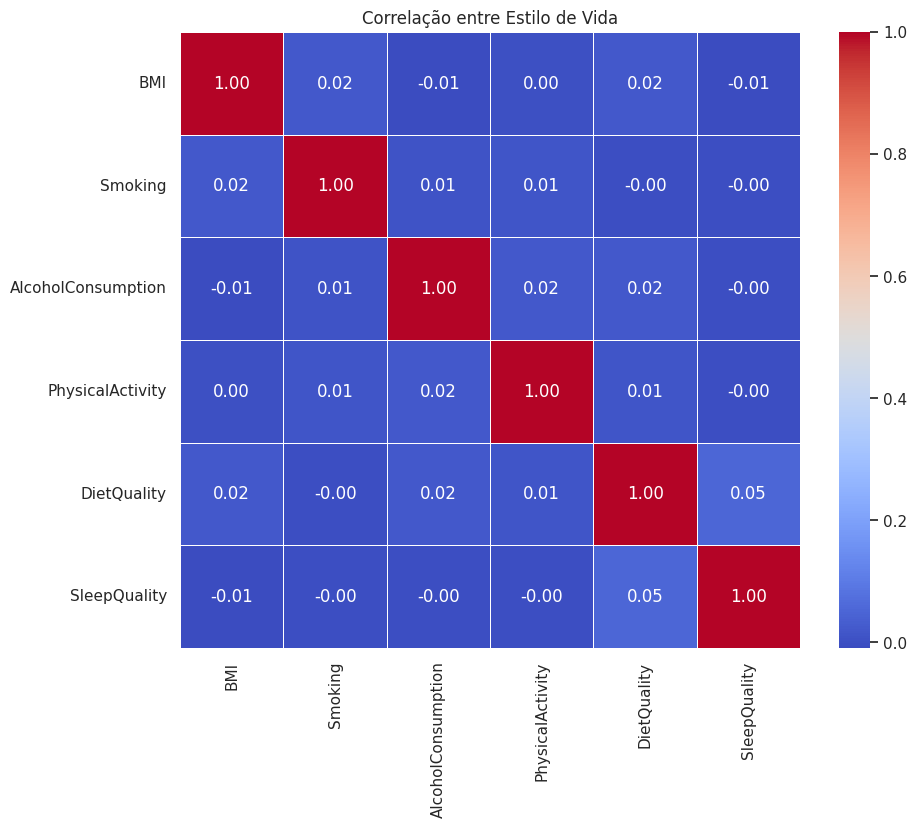

In [43]:
cols = ['BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']
corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlação entre Estilo de Vida')
plt.show()

### Conclusão

Os dados apresentados sobre os hábitos de vida dos pacientes apresentam uma baixa influência quando analisados de forma individual.

Isso demonstra bem a qualidade dos dados adquiridos, onde múltiplos fatores devem ser considerados antes de se realizar uma devida previsão. Há muita variedade para se definir uma resposta olhando apenas para alguns pontos.